# Paper exhibits — Tables 1–2 and the summary figure

Assembles the manuscript's core quantitative exhibits from the saved result tables
(`../week2_rows_full.csv`, `../week3_audit_full.csv`). Tables are written to `../tables/`
and figures to `../figures/` so they can be dropped straight into the paper.

- **Table 1** — experimental design (tasks × shift types).
- **Table 2** — the four trustworthiness properties per model, in-distribution vs shifted,
  with state cluster-bootstrap 95% CIs. *The paper's main quantitative table.*
- **Figure 6** — summary heatmap of degradation by property × model.


In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titleweight": "bold"})

def repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "results" / "week3_audit_full.csv").exists():
            return base
    raise FileNotFoundError("Run from inside the trustworthy-shift repository.")
ROOT = repo_root()
TBL = ROOT / "results" / "tables"; FIG = ROOT / "results" / "figures"
TBL.mkdir(exist_ok=True); FIG.mkdir(exist_ok=True)

audit = pd.read_csv(ROOT / "results" / "week3_audit_full.csv")
early = pd.read_csv(ROOT / "results" / "week2_rows_full.csv")
# join explanation-instability (expl) from the early-warning table
df = audit.merge(early[["task","model","state","year","expl"]],
                 on=["task","model","state","year"], how="left")
print("merged rows:", len(df), "| any missing expl:", df["expl"].isna().any())


merged rows: 531 | any missing expl: False


## Table 1 — experimental design

In [2]:
t1 = (df.groupby(["task", "shift"]).size().unstack(fill_value=0)
        .assign(total=lambda d: d.sum(axis=1)))
t1.loc["ALL"] = t1.sum()
t1.to_csv(TBL / "table1_design.csv")
print("tasks=3 models=3 states=12 years=2014-2018 | source=(CA,2014)")
t1


tasks=3 models=3 states=12 years=2014-2018 | source=(CA,2014)


shift,combined,geographic,temporal,total
task,,,,
income,132,33,12,177
mobility,132,33,12,177
pubcov,132,33,12,177
ALL,396,99,36,531


## Table 2 — four properties, in-distribution vs shifted (per model)

For each model and property: the in-distribution value (source CA-2014 val, averaged over tasks)
and the shifted value (averaged over all 59 target domains and 3 tasks), with a 95% CI from a
**state cluster bootstrap** (states are the independent geographic units). Higher ECE / Brier /
fairness-gap = worse; higher accuracy / AUC = better.

In [3]:
# property -> (in-distribution column, shifted column, higher_is_better)
PROPS = [
    ("Accuracy",          "acc_src",   "acc_tgt",   True),
    ("ROC-AUC",           "auc_src",   "auc_tgt",   True),
    ("PR-AUC",            "ap_src",    "ap_tgt",    True),
    ("ECE (calibration)", "ace_src",   "ace_tgt",   False),
    ("Brier",             "brier_src", "brier_tgt", False),
    ("DP gap (sex)",      "dp_sex_src","dp_sex_tgt",False),
    ("DP gap (race)",     "dp_rac_src","dp_rac_tgt",False),
]

def boot_ci(frame, col, n=400, seed=0):
    rng = np.random.default_rng(seed)
    states = frame["state"].unique()
    means = []
    for _ in range(n):
        pick = rng.choice(states, len(states), replace=True)
        means.append(pd.concat([frame[frame.state == s] for s in pick])[col].mean())
    return np.percentile(means, [2.5, 97.5])

rows = []
for model, g in df.groupby("model"):
    for name, csrc, ctgt, _ in PROPS:
        idv = g[csrc].mean()
        sv = g[ctgt].mean()
        lo, hi = boot_ci(g, ctgt)
        rows.append({"model": model, "property": name,
                     "in-distribution": round(idv, 3),
                     "shifted": round(sv, 3),
                     "shifted 95% CI": f"[{lo:.3f}, {hi:.3f}]"})
# explanation instability (shifted-only: TV distance of SHAP profiles, no ID baseline)
for model, g in df.groupby("model"):
    lo, hi = boot_ci(g, "expl")
    rows.append({"model": model, "property": "Explanation instability",
                 "in-distribution": "-", "shifted": round(g["expl"].mean(), 3),
                 "shifted 95% CI": f"[{lo:.3f}, {hi:.3f}]"})

table2 = pd.DataFrame(rows).sort_values(["model", "property"]).reset_index(drop=True)
table2.to_csv(TBL / "table2_four_property.csv", index=False)
print("wrote", TBL / "table2_four_property.csv")
table2


wrote /Users/feliciasword/Documents/trustworthy-shift/results/tables/table2_four_property.csv


,model,property,in-distribution,shifted,shifted 95% CI
0,logreg,Accuracy,0.766,0.750,"[0.742, 0.758]"
1,logreg,Brier,0.169,0.178,"[0.173, 0.182]"
2,logreg,DP gap (race),0.025,0.041,"[0.037, 0.044]"
3,logreg,DP gap (sex),0.025,0.036,"[0.033, 0.039]"
4,logreg,ECE (calibration),0.036,0.052,"[0.045, 0.059]"
5,logreg,Explanation instability,-,0.034,"[0.029, 0.038]"
6,logreg,PR-AUC,0.673,0.671,"[0.654, 0.690]"
7,logreg,ROC-AUC,0.704,0.707,"[0.701, 0.712]"
8,rf,Accuracy,0.768,0.748,"[0.742, 0.755]"
9,rf,Brier,0.165,0.176,"[0.173, 0.180]"


## Figure 6 — summary heatmap of degradation by property × model

Mean change under shift (positive = degraded), normalized per property to its max so properties
on different scales are comparable. This is the paper's at-a-glance summary of *what breaks where*.

wrote /Users/feliciasword/Documents/trustworthy-shift/results/figures/fig6_summary_heatmap.png


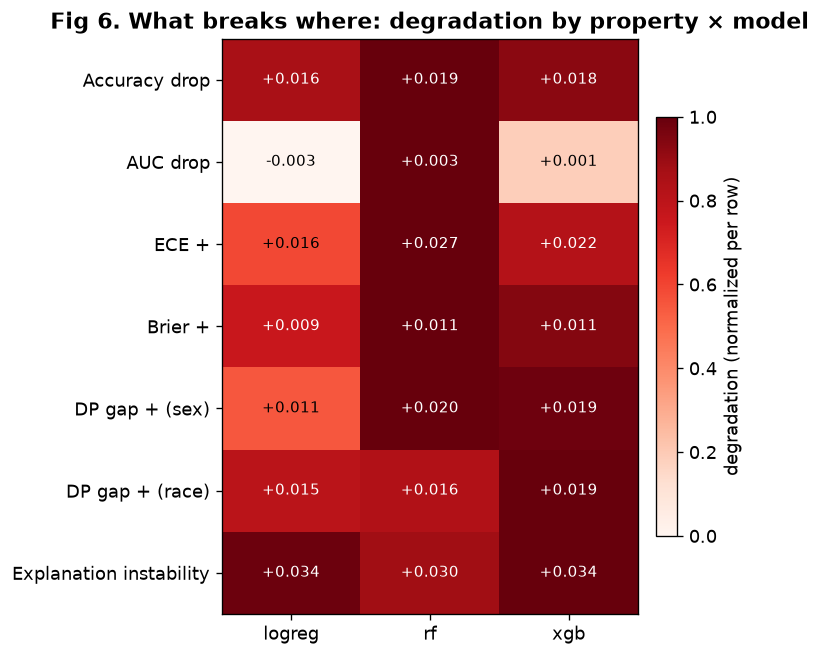

In [4]:
# build degradation matrix: properties (rows) x models (cols)
df["d_acc"]  = df["acc_src"] - df["acc_tgt"]
df["d_auc"]  = df["auc_src"] - df["auc_tgt"]
df["d_ece"]  = df["ace_tgt"] - df["ace_src"]
df["d_brier"]= df["brier_tgt"] - df["brier_src"]
df["d_dpsex"]= df["dp_sex_tgt"] - df["dp_sex_src"]
df["d_dprac"]= df["dp_rac_tgt"] - df["dp_rac_src"]
deg_cols = {"Accuracy drop":"d_acc","AUC drop":"d_auc","ECE +":"d_ece",
            "Brier +":"d_brier","DP gap + (sex)":"d_dpsex","DP gap + (race)":"d_dprac",
            "Explanation instability":"expl"}
models = sorted(df.model.unique())
M = np.array([[df[df.model==m][c].mean() for m in models] for c in deg_cols.values()])
Mn = M / np.abs(M).max(axis=1, keepdims=True)   # normalize each row to [-1,1] by its max |val|

fig, ax = plt.subplots(figsize=(6.4, 5.6))
im = ax.imshow(Mn, cmap="Reds", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(models))); ax.set_xticklabels(models)
ax.set_yticks(range(len(deg_cols))); ax.set_yticklabels(list(deg_cols))
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i,j]:+.3f}", ha="center", va="center",
                color="white" if Mn[i,j] > 0.6 else "black", fontsize=9)
ax.grid(False)
fig.colorbar(im, fraction=0.046, pad=0.04, label="degradation (normalized per row)")
ax.set_title("Fig 6. What breaks where: degradation by property × model")
plt.tight_layout()
fig.savefig(FIG / "fig6_summary_heatmap.png", dpi=200, bbox_inches="tight")
print("wrote", FIG / "fig6_summary_heatmap.png")
plt.show()


**Exports written:**
- `../tables/table1_design.csv`, `../tables/table2_four_property.csv`
- `../figures/fig6_summary_heatmap.png`

Remaining manuscript figures live in the experiment notebooks and are finalized during writing:
Fig 1 (reliability diagrams) and Fig 4 (synthetic appropriate-vs-spurious) come from
`00_synthetic_ground_truth.ipynb` (planned); Fig 2 (SHAP stability), Fig 3 (fairness
trajectories), Fig 5 (incremental early-warning value) are in `01`/`02`. Table 2 is the
quantitative core; Figure 6 is the visual summary.
